In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Data Loading**

In [28]:
df = pd.read_csv("Processed_Flipdata.csv")
print(df.head())
df.tail()

   Unnamed: 0            Model        Colour  Memory  RAM  Battery_  \
0           0  Infinix SMART 7   Night Black      64    4      6000   
1           1  Infinix SMART 7    Azure Blue      64    4      6000   
2           2     MOTOROLA G32  Mineral Gray     128    8      5000   
3           3         POCO C50    Royal Blue      32    2      5000   
4           4  Infinix HOT 30i      Marigold     128    8      5000   

  Rear Camera Front Camera  AI Lens  Mobile Height  \
0        13MP          5MP        1          16.76   
1        13MP          5MP        1          16.76   
2        50MP         16MP        0          16.64   
3         8MP          5MP        0          16.56   
4        50MP          5MP        1          16.76   

                   Processor_   Prize  
0  Unisoc Spreadtrum SC9863A1   7,299  
1  Unisoc Spreadtrum SC9863A1   7,299  
2     Qualcomm Snapdragon 680  11,999  
3          Mediatek Helio A22   5,649  
4                         G37   8,999  


,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
536,637,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,"79,999"
537,638,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.70,Octa Core,"5,998"
538,639,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.76,MediaTek Helio G35,"9,990"
539,641,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.26,"Exynos 1380, Octa Core","38,999"
540,642,OPPO A77,Sky Blue,128,4,5000,50MP,8MP,0,16.66,Mediatek Helio G35,"15,999"


In [29]:
#Dropping the unnecessary column
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [30]:
#Number of rows and columns
print("Number of Rows :",df.shape[0])
print("Number of Clomuns :",df.shape[1])

Number of Rows : 541
Number of Clomuns : 11


In [31]:
#knowing the various data types  
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    str    
 1   Colour         541 non-null    str    
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    str    
 6   Front Camera   541 non-null    str    
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    str    
 10  Prize          541 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 46.6 KB


In [32]:
#Renaming the column
df.rename(columns={"Prize": "Price"}, inplace=True)

In [33]:
#Changing data type
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace(",", "")   # remove commas
)

df["Price"] = pd.to_numeric(df["Price"], errors="raise").astype("Int64")

In [37]:
df['Rear Camera'] = df['Rear Camera'].str[:-2]
df['Front Camera'] = df['Front Camera'].str[:-2]

df['Rear Camera'] = df['Rear Camera'].astype(int)
df['Front Camera'] = df['Front Camera'].astype(int)

**Handling missing Data**

In [38]:
df.isnull().sum()

Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Price            0
dtype: int64

The file as no null values but its showing here.

**Handling Duplicate data**

In [39]:
df[df.duplicated()]


,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Price
27,vivo T2x 5G,Marine Blue,128,6,5000,50,8,0,16.71,Dimensity 6020,13999
48,MOTOROLA e32,Arctic Blue,64,4,5000,50,8,0,16.51,Mediatek Helio G37,7999
91,SAMSUNG Galaxy F14 5G,B.A.E. Purple,128,4,6000,50,13,0,16.76,"Exynos 1330, Octa Core",13490
132,SAMSUNG Galaxy F14 5G,OMG Black,128,6,6000,50,13,0,16.76,"Exynos 1330, Octa Core",14490
247,redmi min,M3),16,4,1000,0,0,0,4.57,Spreadtrum,920
344,Tecno Spark 9T,Turquoise Cyan,64,4,5000,50,8,0,16.76,MediaTek Helio G35,9290
352,POCO X4 Pro 5G,Laser Black,128,8,5000,64,16,0,16.94,Qualcomm Snapdragon 695 5G,19499
424,realme C30s,Stripe Black,64,4,5000,8,5,0,16.51,Unisoc SC9863A/ Unisoc SC9863A1,8499
437,vivo Y100 5G,Pacific Blue,128,8,4500,64,16,0,16.21,Mediatek Dimensity 900,23999
480,POCO C31,Royal Blue,64,4,5000,13,5,0,16.59,MediaTek G35,8999


In [ ]:
df = df.drop_duplicates(keep="first")

In [ ]:
print("Number of Rows :",df.shape[0])
print("Number of Clomuns :",df.shape[1])

Number of Rows : 531
Number of Clomuns : 11


# **Detecting Outliers using Boxplot**

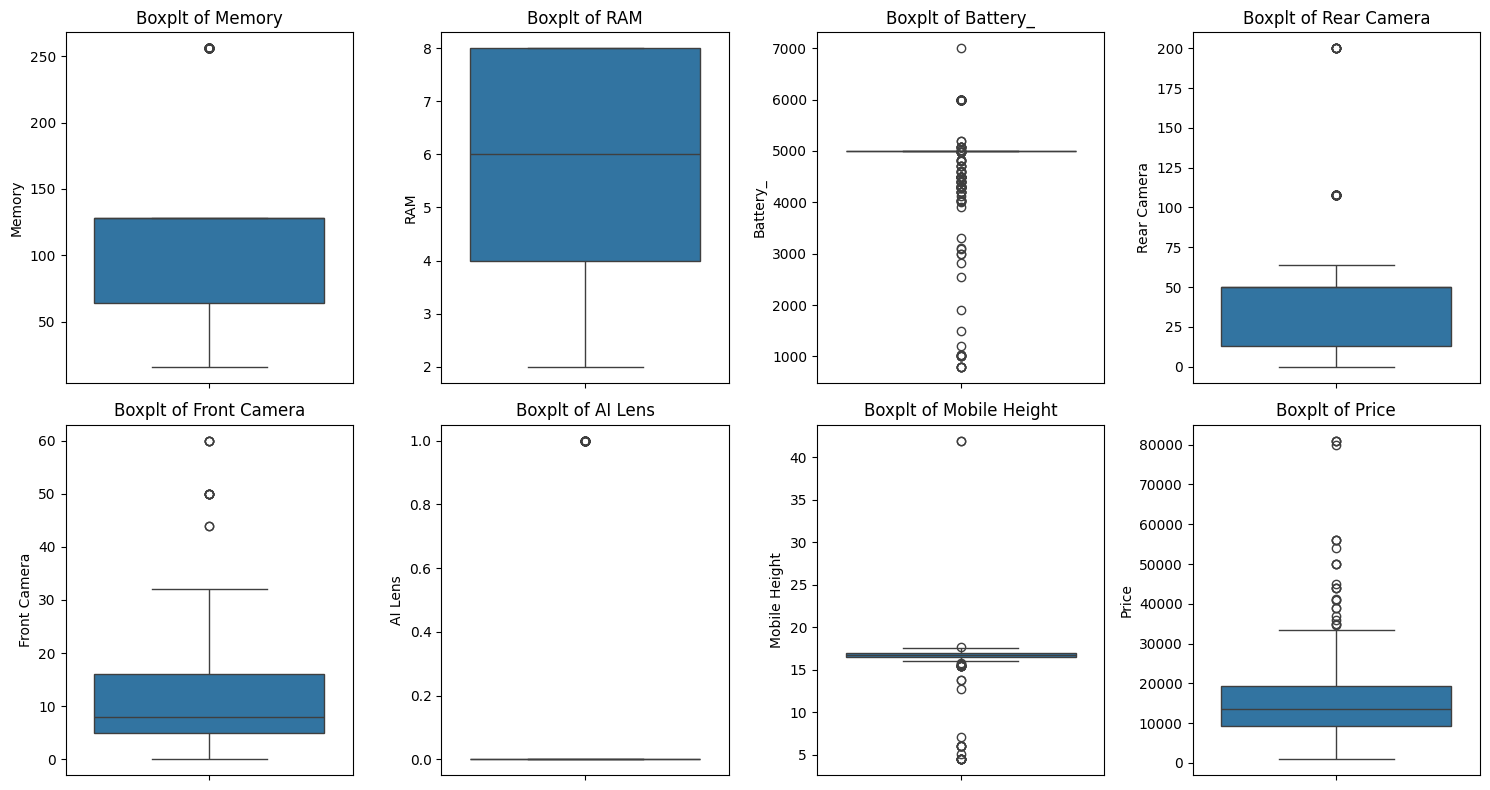

In [44]:
numeric_col = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15,8))
for i , col in enumerate(numeric_col,1):
    plt.subplot(2,4,i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplt of {col}")
plt.tight_layout()
plt.show()


# **Capping Method to remove outliers**

In [47]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

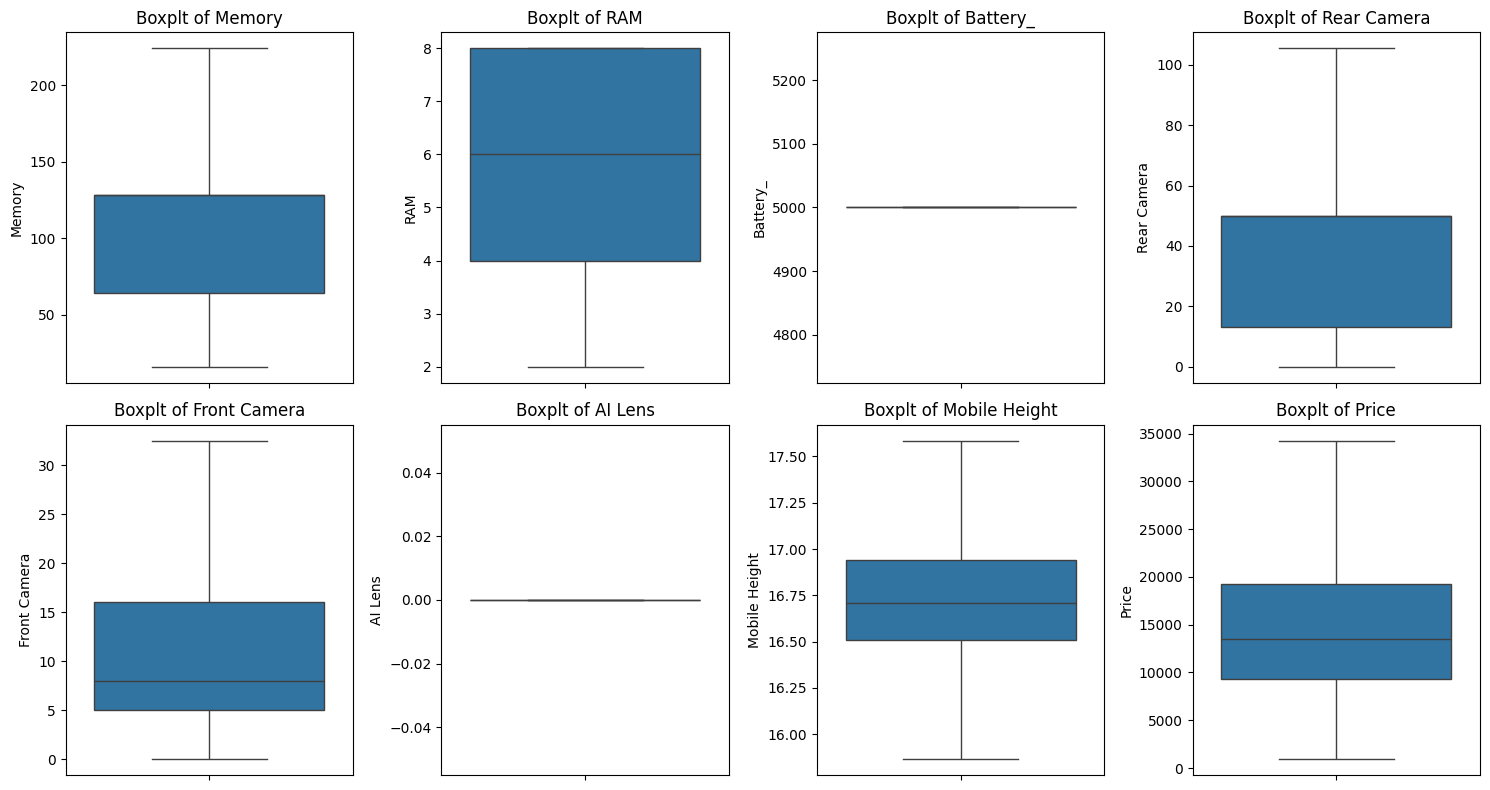

In [48]:
numeric_col = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15,8))
for i , col in enumerate(numeric_col,1):
    plt.subplot(2,4,i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplt of {col}")
plt.tight_layout()
plt.show()


# Univariate Analysis

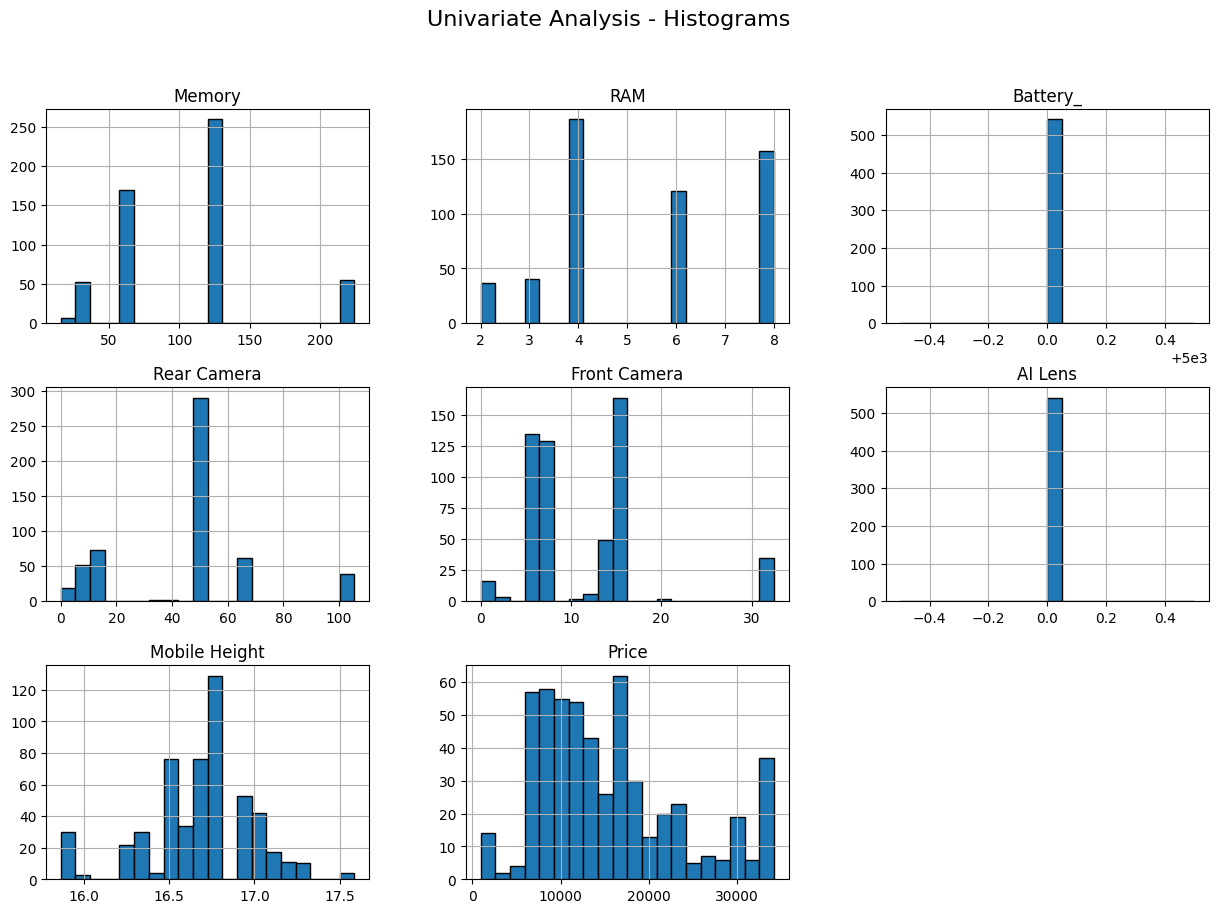

In [49]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle("Univariate Analysis - Histograms", fontsize=16)
plt.show()

## **Insights**
**Memory**
- Most values are under 64-128GB which means market is centered on mid-storage phones.

**RAM**
- Common values = 4BG, 6GB AND 8GB but 4GB has the highest demand.

**Battery**
- The only demand of battery is 5000 mAh.

**Rear Camera**
- In majority of phones use 50MP of rear camera.

**Front Camera**
- Most of thr phones have camera between 5-15 MP but few high values cameras are of 32MP.

**Mobile Height**
- Most mobiles have a standard height between 16-17cm.

**Price**
- Most phones are between 8k-22k and few premium mobiles are above 25k which shows that people buy mid-range and budget friendly phones.

# Bivariate Analysis

<function matplotlib.pyplot.show(close=None, block=None)>

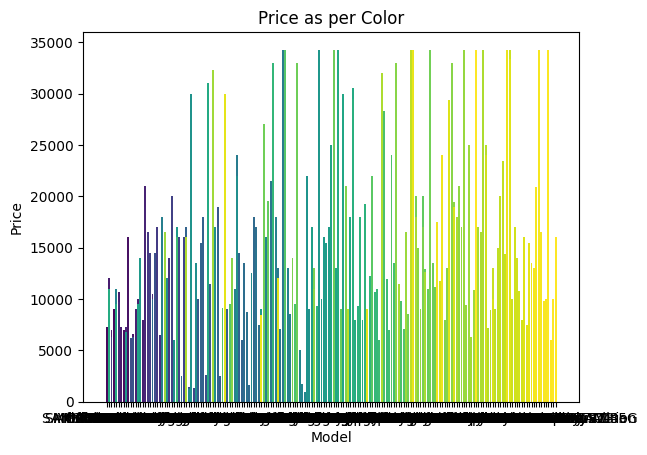

In [52]:
colors = plt.cm.viridis(np.linspace(0,1,len(df['Model'])))
plt.bar(df['Model'],df['Price'],color=colors)
plt.title("Price as per Color")
plt.xlabel("Model")
plt.ylabel("Price")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

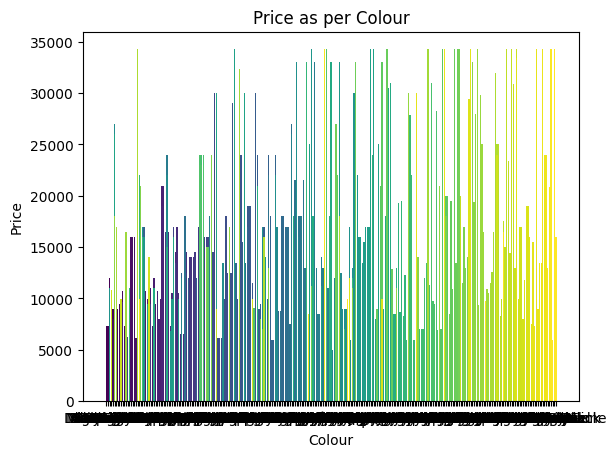

In [53]:
colors = plt.cm.viridis(np.linspace(0,1,len(df['Colour'])))
plt.bar(df['Colour'],df['Price'],color=colors)
plt.title("Price as per Colour")
plt.xlabel("Colour")
plt.ylabel("Price")
plt.show

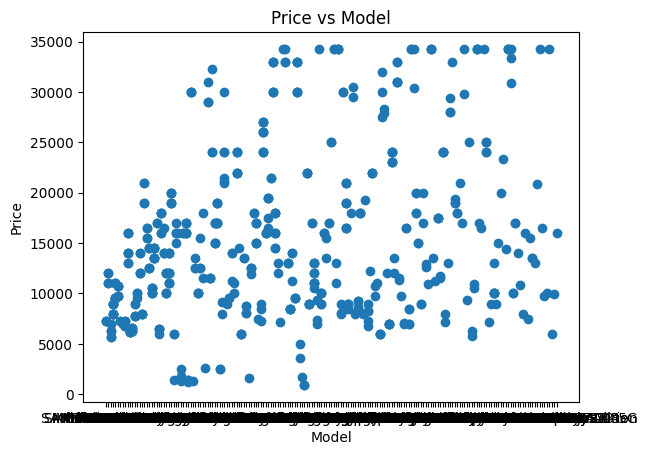

In [54]:
plt.scatter(df['Model'], df['Price'])
plt.xlabel('Model')
plt.ylabel('Price')
plt.title('Price vs Model')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_10652\3696636759.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Model', y='Price', data=df, ci=None)


<Axes: xlabel='Model', ylabel='Price'>

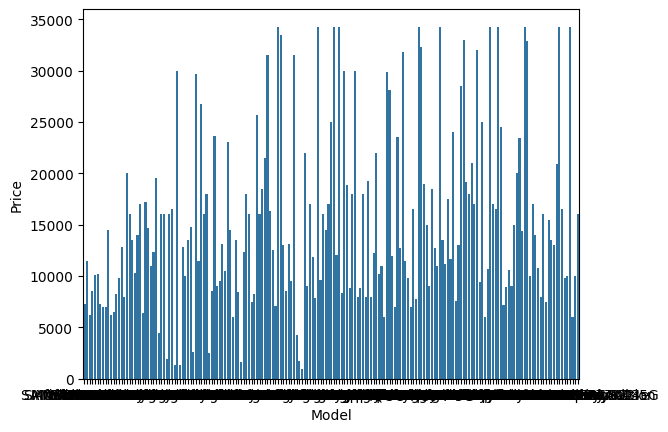

In [56]:
sns.barplot(x='Model', y='Price', data=df, ci=None)

NameError: name 'Model' is not defined

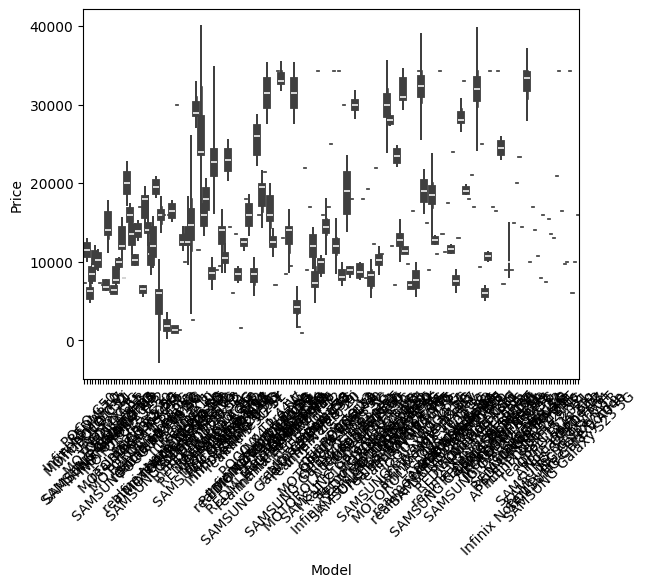

In [58]:
sns.violinplot(x='Model', y='Price', data=df)
plt.xticks(rotation=45)
plt.title(f"{Model} vs {Price}")
plt.show()

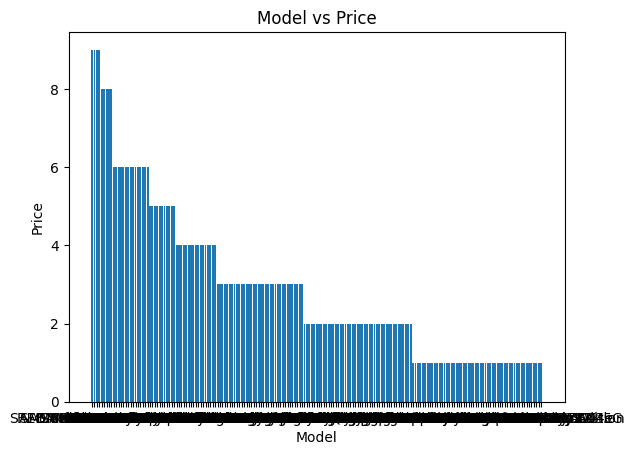

In [59]:
model_counts = df['Model'].value_counts()

plt.bar(model_counts.index, model_counts.values)
plt.xlabel("Model")
plt.ylabel("Price")
plt.title("Model vs Price")
plt.show()

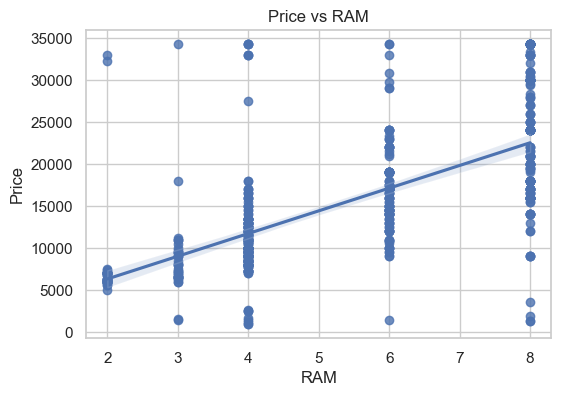

In [63]:
sns.set(style="whitegrid")

# Price vs RAM
plt.figure(figsize=(6,4))
sns.regplot(data=df, x="RAM", y="Price")
plt.title("Price vs RAM")
plt.show()

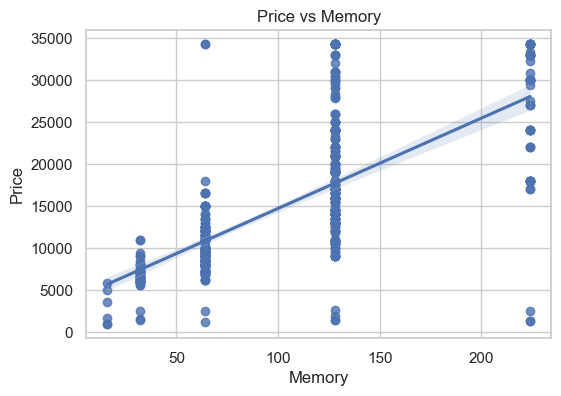

In [65]:
sns.set(style="whitegrid")
# Price vs Memory
plt.figure(figsize=(6,4))
sns.regplot(data=df, x="Memory", y="Price")
plt.title("Price vs Memory")
plt.show()

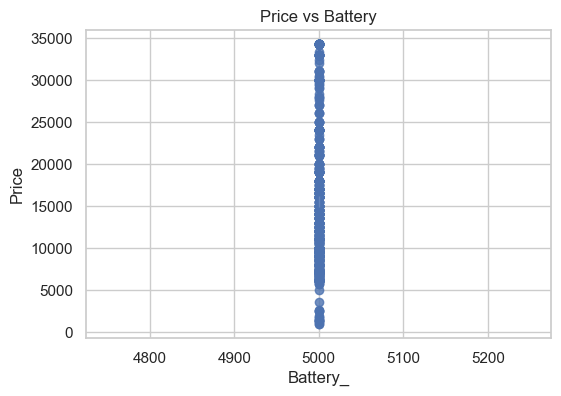

In [69]:
sns.set(style="whitegrid")

# Price vs Battery
plt.figure(figsize=(6,4))
sns.regplot(data=df, x="Battery_", y="Price")
plt.title("Price vs Battery")
plt.show()

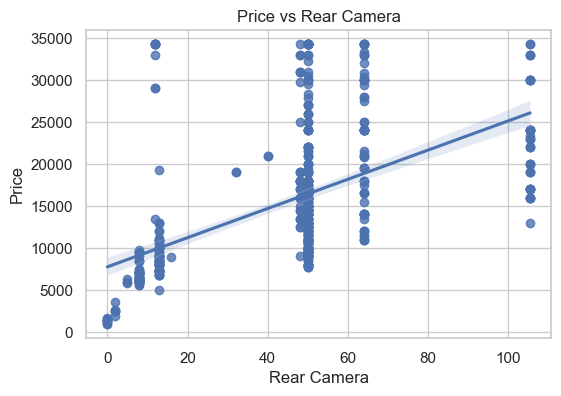

In [68]:
sns.set(style="whitegrid")

# Price vs Rear Camera
plt.figure(figsize=(6,4))
sns.regplot(data=df, x="Rear Camera", y="Price")
plt.title("Price vs Rear Camera")
plt.show()